<a href="https://colab.research.google.com/github/khan5125/ML-DL-Models/blob/main/Predict_Employee_Performance_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Predict Employee Performance with Machine Learning**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/Extended_Employee_Performance_and_Productivity_Data.csv')

In [5]:
df.head(2)

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  object 
 5   Hire_Date                    100000 non-null  object 
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  object 
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 non-null  int64  
 13  

In [7]:
df.columns

Index(['Employee_ID', 'Department', 'Gender', 'Age', 'Job_Title', 'Hire_Date',
       'Years_At_Company', 'Education_Level', 'Performance_Score',
       'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled',
       'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size',
       'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score',
       'Resigned'],
      dtype='object')

In [8]:
# Drop some columns

df.drop(['Employee_ID', 'Hire_Date', 'Work_Hours_Per_Week', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours', 'Resigned'], axis=1, inplace=True)

In [9]:
df

,Department,Gender,Age,Job_Title,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Projects_Handled,Overtime_Hours,Promotions,Employee_Satisfaction_Score
0,IT,Male,55,Specialist,2,High School,5,6750.0,32,22,0,2.63
1,Finance,Male,29,Developer,0,High School,5,7500.0,34,13,2,1.72
2,Finance,Male,55,Specialist,8,High School,3,5850.0,27,6,0,3.17
3,Customer Support,Female,48,Analyst,7,Bachelor,2,4800.0,10,28,1,1.86
4,Engineering,Female,36,Analyst,3,Bachelor,2,4800.0,11,29,1,1.25
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,Finance,Male,27,Technician,1,Bachelor,4,4900.0,46,5,2,1.28
99996,IT,Female,36,Consultant,6,Master,5,8250.0,35,7,1,3.48
99997,Operations,Male,53,Analyst,8,High School,2,4800.0,13,6,1,2.60
99998,HR,Female,22,Consultant,9,High School,5,8250.0,43,10,1,3.10


In [10]:
df.isna().sum().sum()

np.int64(0)

In [11]:
df.duplicated().sum()

np.int64(0)

No Duplicates and "na" Values

In [12]:
df.groupby('Department')['Monthly_Salary'].mean().sort_values(ascending=False)

,Monthly_Salary
Department,
Engineering,6417.246258
IT,6414.598868
Sales,6413.154109
Operations,6412.306592
Customer Support,6403.881792
HR,6400.355839
Finance,6398.575893
Legal,6391.275409
Marketing,6377.857525


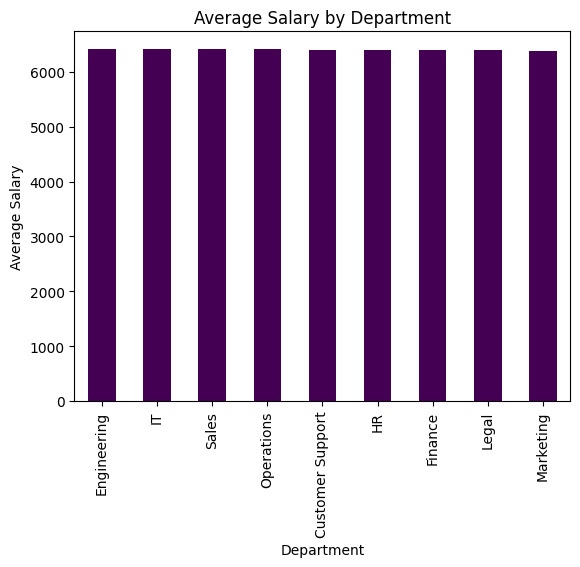

In [13]:
from matplotlib import colors
df.groupby('Department')['Monthly_Salary'].mean().sort_values(ascending=False).plot(kind='bar', colormap="viridis")
plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Average Salary')
plt.show()

In [14]:
df.head(2)

,Department,Gender,Age,Job_Title,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Projects_Handled,Overtime_Hours,Promotions,Employee_Satisfaction_Score
0,IT,Male,55,Specialist,2,High School,5,6750.0,32,22,0,2.63
1,Finance,Male,29,Developer,0,High School,5,7500.0,34,13,2,1.72


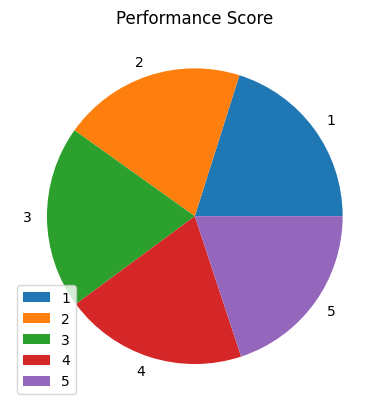

In [15]:
df['Performance_Score'].value_counts().plot(kind="pie", legend=True)
plt.title('Performance Score')
plt.ylabel("")
plt.show()

In [16]:
df['Gender'].value_counts()

,count
Gender,
Male,48031
Female,48001
Other,3968


In [17]:
df.groupby("Department")["Years_At_Company"].mean().sort_values(ascending=False)

,Years_At_Company
Department,
Marketing,4.504458
Engineering,4.488956
Customer Support,4.487675
Finance,4.481429
HR,4.473996
Operations,4.473571
Sales,4.469430
Legal,4.469059
IT,4.435990


In [18]:
df['Department'].value_counts()

,count
Department,
Marketing,11216
Finance,11200
Operations,11181
IT,11131
Sales,11122
Legal,11118
Customer Support,11116
HR,10960
Engineering,10956


In [19]:
df['Overtime_Hours'].describe()

,Overtime_Hours
count,100000.000000
mean,14.514930
std,8.664026
min,0.000000
25%,7.000000
50%,15.000000
75%,22.000000
max,29.000000


In [20]:
df.describe()

,Age,Years_At_Company,Performance_Score,Monthly_Salary,Projects_Handled,Overtime_Hours,Promotions,Employee_Satisfaction_Score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.029410,4.476070,2.995430,6403.211000,24.431170,14.514930,0.999720,2.999088
std,11.244121,2.869336,1.414726,1372.508717,14.469584,8.664026,0.815872,1.150719
min,22.000000,0.000000,1.000000,3850.000000,0.000000,0.000000,0.000000,1.000000
25%,31.000000,2.000000,2.000000,5250.000000,12.000000,7.000000,0.000000,2.010000
50%,41.000000,4.000000,3.000000,6500.000000,24.000000,15.000000,1.000000,3.000000
75%,51.000000,7.000000,4.000000,7500.000000,37.000000,22.000000,2.000000,3.990000
max,60.000000,10.000000,5.000000,9000.000000,49.000000,29.000000,2.000000,5.000000


In [21]:
df.groupby('Department')['Overtime_Hours'].mean().sort_values(ascending=False)

,Overtime_Hours
Department,
IT,14.672716
Engineering,14.593282
HR,14.577099
Legal,14.548390
Operations,14.520794
Sales,14.513757
Marketing,14.482792
Customer Support,14.383951
Finance,14.344911


In [22]:
df.groupby(['Gender', 'Department'])['Overtime_Hours'].mean().sort_values(ascending=False)

Gender  Department      
Other   Operations          15.123874
        Legal               14.741176
Female  IT                  14.703857
        Engineering         14.698030
Male    Sales               14.666164
        IT                  14.665673
Female  HR                  14.651711
Other   Finance             14.644681
Female  Legal               14.604333
        Marketing           14.601631
Other   Sales               14.581818
Male    Engineering         14.559229
        HR                  14.511971
Female  Operations          14.503520
Male    Operations          14.488106
        Legal               14.475813
Female  Customer Support    14.471374
Other   HR                  14.467641
        IT                  14.388889
Male    Marketing           14.386959
        Finance             14.367171
Female  Sales               14.357993
Male    Customer Support    14.315895
Female  Finance             14.296599
Other   Marketing           14.194954
        Customer Support    14.166667
        Engineering         13.746544
Name: Overtime_Hours, dtype: float64

In [23]:
df.groupby(['Department', 'Performance_Score'])['Overtime_Hours'].mean()

Department        Performance_Score
Customer Support  1                    14.304464
                  2                    14.418025
                  3                    14.748092
                  4                    14.149146
                  5                    14.300226
Engineering       1                    14.464953
                  2                    14.712191
                  3                    14.595946
                  4                    14.570896
                  5                    14.618502
Finance           1                    14.387211
                  2                    14.240463
                  3                    14.283740
                  4                    14.343501
                  5                    14.475252
HR                1                    14.711942
                  2                    14.758087
                  3                    14.484793
                  4                    14.517415
                  5                    14.412626
IT                1                    14.764365
                  2                    14.413256
                  3                    14.875000
                  4                    14.725526
                  5                    14.594464
Legal             1                    14.836426
                  2                    14.607808
                  3                    14.237746
                  4                    14.473133
                  5                    14.568725
Marketing         1                    14.551192
                  2                    14.334375
                  3                    14.625000
                  4                    14.537079
                  5                    14.356582
Operations        1                    14.587394
                  2                    14.171546
                  3                    14.698004
                  4                    14.304405
                  5                    14.836991
Sales             1                    14.484522
                  2                    14.427863
                  3                    14.610071
                  4                    14.496665
                  5                    14.549496
Name: Overtime_Hours, dtype: float64

In [24]:
df_num = df.select_dtypes(include=["number"])

In [25]:
df_num.corr()['Performance_Score'].sort_values(ascending=False)

,Performance_Score
Performance_Score,1.000000
Monthly_Salary,0.510035
Employee_Satisfaction_Score,0.001696
Years_At_Company,0.001598
Age,0.001598
Projects_Handled,0.000640
Overtime_Hours,-0.001312
Promotions,-0.003501




*   (-1) Represent Strong Negative (Opposite)
*   (1) Represent Strong Positive (Similar)



In [26]:
df.head(1)

,Department,Gender,Age,Job_Title,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Projects_Handled,Overtime_Hours,Promotions,Employee_Satisfaction_Score
0,IT,Male,55,Specialist,2,High School,5,6750.0,32,22,0,2.63


In [27]:
y = df['Performance_Score']
X = df[['Years_At_Company', 'Monthly_Salary', 'Overtime_Hours', 'Promotions', 'Employee_Satisfaction_Score']]

In [28]:
X.head(1)

,Years_At_Company,Monthly_Salary,Overtime_Hours,Promotions,Employee_Satisfaction_Score
0,2,6750.0,22,0,2.63


In [29]:
from sklearn.preprocessing import StandardScaler

In [30]:
scaler = StandardScaler()

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [32]:
# Scaled X_train

X_train = scaler.fit_transform(X_train)

In [33]:
# Scaled X_test

X_test = scaler.transform(X_test)

In [34]:
import warnings
warnings.filterwarnings("ignore")

In [35]:
from sklearn.metrics import accuracy_score

In [36]:
def modelperformance(prediction):
  print(("Accuracy score on model is {}".format(accuracy_score(y_test,prediction))))

In [37]:
from sklearn.model_selection import GridSearchCV


In [38]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

In [39]:
log_model.predict(X_test)
log_predictions = log_model.predict(X_test)

In [40]:
modelperformance(log_predictions)

Accuracy score on model is 0.3146


In [41]:
from sklearn.neighbors import KNeighborsClassifier
param_grid = {"n_neighbors": [3,5,7,9,11],
              "weights": ["uniform", "distance"]}

In [42]:
gridkn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)

In [43]:
gridkn.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']})

In [44]:
gridkn.best_params_

{'n_neighbors': 3, 'weights': 'distance'}

In [45]:
predictions = gridkn.predict(X_test)

In [46]:
modelperformance(predictions)

Accuracy score on model is 0.50095


In [47]:
from sklearn.svm import SVC
svm = SVC()


In [48]:
param_grid = {
    "C": [0.01, 0.1, 0.5, 1],
    "kernel": ["linear", "poly", "rbf"]
}

In [49]:
gridsvc = GridSearchCV(SVC(), param_grid, cv=5)

In [ ]:
gridsvc.fit(X_train, y_train)

In [ ]:
y_pred = gridsvc.predict(X_test)

In [ ]:
modelperformance(y_pred)

**Prediction score: 93%**

In my system ; its not working properly